# Import necessary libraries

In [1]:
import requests
import json
import pandas as pd 
import os
import time
from collections import Counter
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import MultipleLocator
import networkx as nx
import warnings
warnings.simplefilter("ignore")

# Publications Retrieval

In [2]:
# Define the path for local file storage
local_file_path = 'api_responses.json'

def get_author_publications(author_name):
    # Initialize the starting index and the number of results per call
    f = 0
    h = 500
    all_publications = []
    
    # Initialize data as an empty dictionary
    # Keys : Authors
    # Values : JSON responses 
    data = {}

    # Load existing data from the local file if it exists
    if os.path.exists(local_file_path):
        with open(local_file_path, 'r') as file:
            data = json.load(file)
        
        # Check if the author_name is already in the local file
        if author_name in data:
            return data[author_name]

    # If no existing data for the author in the local file, proceed with API requests
    while True:
        # Construct the query URL with the current starting index
        url = f"https://dblp.org/search/publ/api?q={author_name}&format=json&h={h}&f={f}"
        
        # Send a GET request to the DBLP API
        r = requests.get(url)
        
        # Check the response
        if r.status_code == 200:
            # Load the JSON response
            j = json.loads(r.text)

            # Extract the hits from the JSON response
            hits = j['result']['hits'].get('hit', [])
            
            # If no hits are returned, break the loop
            if not hits:
                break

            # Iterate through each hit
            for hit in hits:
                # Extract the authors for the current hit
                authors = hit['info']['authors']['author']
                
                # Convert authors to a list if it's a dictionary (i.e., single-author publication)
                if isinstance(authors, dict):
                    authors = [authors]

                # Check if the desired author is in the list of authors for this hit
                if any(author['text'] == author_name for author in authors):
                    all_publications.append(hit)

            # Increment the starting index for the next API call
            f += h
        
        else:
            print("Error:", r.status_code)
            print("Response content:", r.content)
            break
        
        # Add a delay to avoid hitting API rate limits
        time.sleep(1)

    # At the end of the function, update the local file with the retrieved data for the author_name
    # No need for API request next time
    data[author_name] = all_publications
    
    # Save the updated data to the local file
    with open(local_file_path, 'w') as file:
        json.dump(data, file)
    
    return all_publications

In [3]:
# Test the function with a specific author
author_name = "Ling Shao 0001"
author_pubs = get_author_publications(author_name)
if author_pubs is not None:
    print(f"{author_name} has {len(author_pubs)} publications.")
else:
    print("Failed to retrieve publication count.")

Ling Shao 0001 has 993 publications.


In [4]:
# Study 3 specific authors 
authors = ["Ling Shao 0001", "Yonina C. Eldar", "Rolf Drechsler"]
author_pubs = [get_author_publications(authors[i]) for i in range(len(authors))]

In [5]:
# Show the number of publications for each author
for author, pubs in zip(authors, author_pubs):
    if pubs is not None:
        print(f"{author} has {len(pubs)} publications.")
    else:
        print("Failed to retrieve publication count.")

Ling Shao 0001 has 993 publications.
Yonina C. Eldar has 1098 publications.
Rolf Drechsler has 1030 publications.


In [6]:
# Convert JSON objects to DataFrame
merged_df = [pd.json_normalize(author_pubs[i]) for i in range(len(author_pubs))]

# Take a look at a dataframe
merged_df[0].head()

,@score,@id,url,info.authors.author,info.title,info.venue,info.pages,info.year,info.type,info.access,info.key,info.doi,info.ee,info.url,info.volume,info.number,info.publisher,info.authors.author.@pid,info.authors.author.text
0,25,2555840,URL#2555840,"[{'@pid': '79/1648', 'text': 'Matej Kristan'},...",The Ninth Visual Object Tracking VOT2021 Chall...,ICCVW,2711-2738,2021,Conference and Workshop Papers,closed,conf/iccvw/KristanMLFPKCDZ21,10.1109/ICCVW54120.2021.00305,https://doi.org/10.1109/ICCVW54120.2021.00305,https://dblp.org/rec/conf/iccvw/KristanMLFPKCDZ21,NaN,NaN,NaN,NaN,NaN
1,21,4429795,URL#4429795,"[{'@pid': '33/5593', 'text': 'Nikolaos V. Boul...",Introduction of New Associate Editors.,IEEE Trans. Circuits Syst. Video Technol.,253-263,2016,Journal Articles,closed,journals/tcsv/BoulgourisBCCCR16,10.1109/TCSVT.2016.2518782,https://doi.org/10.1109/TCSVT.2016.2518782,https://dblp.org/rec/journals/tcsv/BoulgourisB...,26,2,NaN,NaN,NaN
2,16,3388083,URL#3388083,"[{'@pid': '202/2128', 'text': 'Abdelrahman Abd...",NTIRE 2019 Challenge on Real Image Denoising: ...,CVPR Workshops,2197-2210,2019,Conference and Workshop Papers,open,conf/cvpr/AbdelhamedTB19,10.1109/CVPRW.2019.00273,http://openaccess.thecvf.com/content_CVPRW_201...,https://dblp.org/rec/conf/cvpr/AbdelhamedTB19,NaN,NaN,NaN,NaN,NaN
3,15,3335301,URL#3335301,"[{'@pid': '49/10082', 'text': 'Lingli Zhou'}, ...",Depth Embedded Recurrent Predictive Parsing Ne...,IEEE Trans. Intell. Transp. Syst.,4643-4654,2019,Journal Articles,closed,journals/tits/ZhouZLSY19,10.1109/TITS.2019.2909053,https://doi.org/10.1109/TITS.2019.2909053,https://dblp.org/rec/journals/tits/ZhouZLSY19,20,12,NaN,NaN,NaN
4,13,2457882,URL#2457882,"[{'@pid': '125/2564', 'text': 'Shiyu Liu'}, {'...",Built-in Depth-Semantic Coupled Encoding for S...,IEEE Trans. Intell. Transp. Syst.,5520-5534,2021,Journal Articles,closed,journals/tits/LiuZ0Y21,10.1109/TITS.2020.2987819,https://doi.org/10.1109/TITS.2020.2987819,https://dblp.org/rec/journals/tits/LiuZ0Y21,22,9,NaN,NaN,NaN


# Data Cleaning

In [7]:
def extract_authors(author_list):
    if isinstance(author_list, list):
        return ", ".join([a['text'] for a in author_list])
    return None

In [8]:
cols_to_keep = [
    '@id',
    'info.authors.author',
    'info.title',
    'info.venue',
    'info.year',
    'info.type'
]

for i in range(len(merged_df)):
    merged_df[i] = merged_df[i][cols_to_keep].copy()
    
    merged_df[i].rename(columns={
        '@id': 'id',
        'info.authors.author': 'authors',
        'info.title': 'title',
        'info.venue': 'venue',
        'info.year': 'year',
        'info.type': 'type'
    }, inplace=True)

    merged_df[i]['authors'] = merged_df[i]['authors'].apply(extract_authors)

In [11]:
merged_df[0]

,id,authors,title,venue,year,type
0,2555840,"Matej Kristan, Jirí Matas, Ales Leonardis, Mic...",The Ninth Visual Object Tracking VOT2021 Chall...,ICCVW,2021,Conference and Workshop Papers
1,4429795,"Nikolaos V. Boulgouris, David R. Bull, Marco C...",Introduction of New Associate Editors.,IEEE Trans. Circuits Syst. Video Technol.,2016,Journal Articles
2,3388083,"Abdelrahman Abdelhamed, Radu Timofte, Michael ...",NTIRE 2019 Challenge on Real Image Denoising: ...,CVPR Workshops,2019,Conference and Workshop Papers
3,3335301,"Lingli Zhou, Haofeng Zhang 0001, Yang Long 000...",Depth Embedded Recurrent Predictive Parsing Ne...,IEEE Trans. Intell. Transp. Syst.,2019,Journal Articles
4,2457882,"Shiyu Liu, Haofeng Zhang 0001, Ling Shao 0001,...",Built-in Depth-Semantic Coupled Encoding for S...,IEEE Trans. Intell. Transp. Syst.,2021,Journal Articles
...,...,...,...,...,...,...
988,6824228,"Ihor O. Kirenko, Ling Shao 0001",Local Objective Metrics of Blocking Artifacts ...,ICME,2007,Conference and Workshop Papers
989,6824399,"Ling Shao 0001, Harm van der Heijden",Integrated Image Enhancement and Artifacts Red...,ICME,2007,Conference and Workshop Papers
990,6824400,"Ling Shao 0001, Meng Zhao",Order Statistic Filters for Image Interpolation.,ICME,2007,Conference and Workshop Papers
991,6987921,"Ling Shao 0001, Ihor O. Kirenko, Ping Li 0006",Feature classification based on local informat...,EUSIPCO,2006,Conference and Workshop Papers


# Exploratory Data Analysis

In [12]:
# Create a list with the publication counts for each author
pubs_count = [len(author_pubs[i]) for i in range(len(author_pubs))]

# Sort authors and pubs_count in descending order based on pubs_count
sorted_data = sorted(zip(authors, pubs_count), key=lambda x: x[1], reverse=True)
sorted_authors = [item[0] for item in sorted_data]
sorted_pubs_count = [item[1] for item in sorted_data]

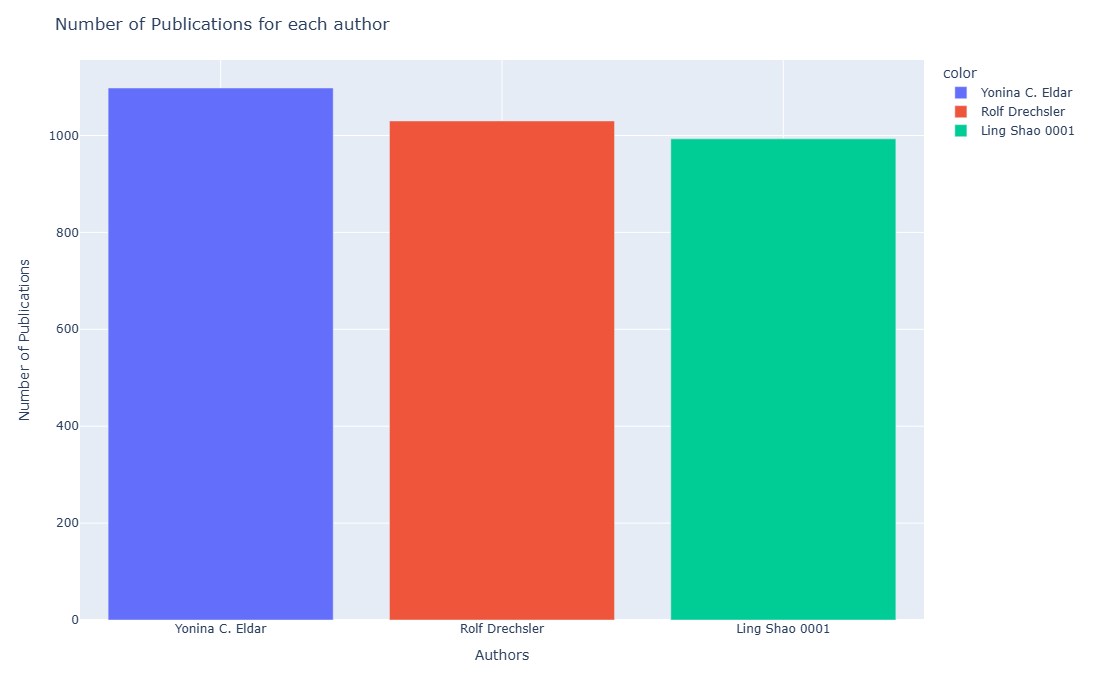

In [13]:
# Visualize the number of publications for each author using 'plotly.express'
fig = px.bar(x=sorted_authors, y=sorted_pubs_count, color=sorted_authors)

layout = dict(
autosize=False,
title=r"Number of Publications for each author",
xaxis=dict(title='Authors', showgrid=True),
yaxis=dict(title='Number of Publications'),
width=1000,
height=700,
)

fig.update_layout(layout).show()

In [16]:
# Create a list with the publication count per year for each author
pubs_time = [merged_df[i].groupby(['year'])['id'].count().reset_index() for i in range(len(merged_df))]
pubs_time[0]

,year,id
0,2004,1
1,2006,4
2,2007,12
3,2008,5
4,2009,5
5,2010,12
6,2011,18
7,2012,12
8,2013,31
9,2014,38


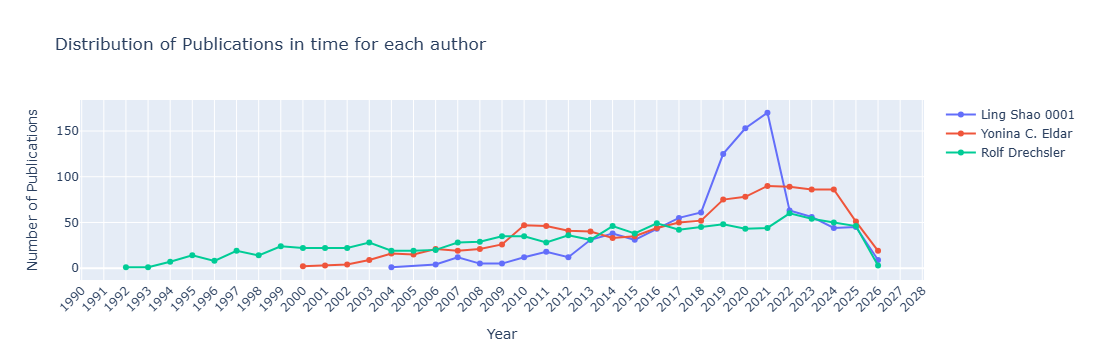

In [17]:
# Visualize the number of publications in time for each author
fig = go.Figure()

for df, auth in zip(pubs_time, authors):
    # Convert 'year' column to numeric for completeness shake
    df["year"] = pd.to_numeric(df["year"])
    fig.add_trace(
        go.Scatter(
            x=df["year"],
            y=df["id"],
            mode="lines+markers",
            name=auth
        )
    )
    
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Publications",
    title="Distribution of Publications in time for each author",
    xaxis=dict(
        tickangle=-45,
        tickmode='linear',
        dtick=1
    )
)

fig.show()

In [18]:
# Create a list with the publication count for each type for each author
pubs_type = [merged_df[i].groupby(['type'])['id'].count().reset_index() for i in range(len(merged_df))]
pubs_type[2]

,type,id
0,Books and Theses,14
1,Conference and Workshop Papers,784
2,Data and Artifacts,3
3,Editorship,15
4,Informal and Other Publications,36
5,Journal Articles,173
6,Parts in Books or Collections,5


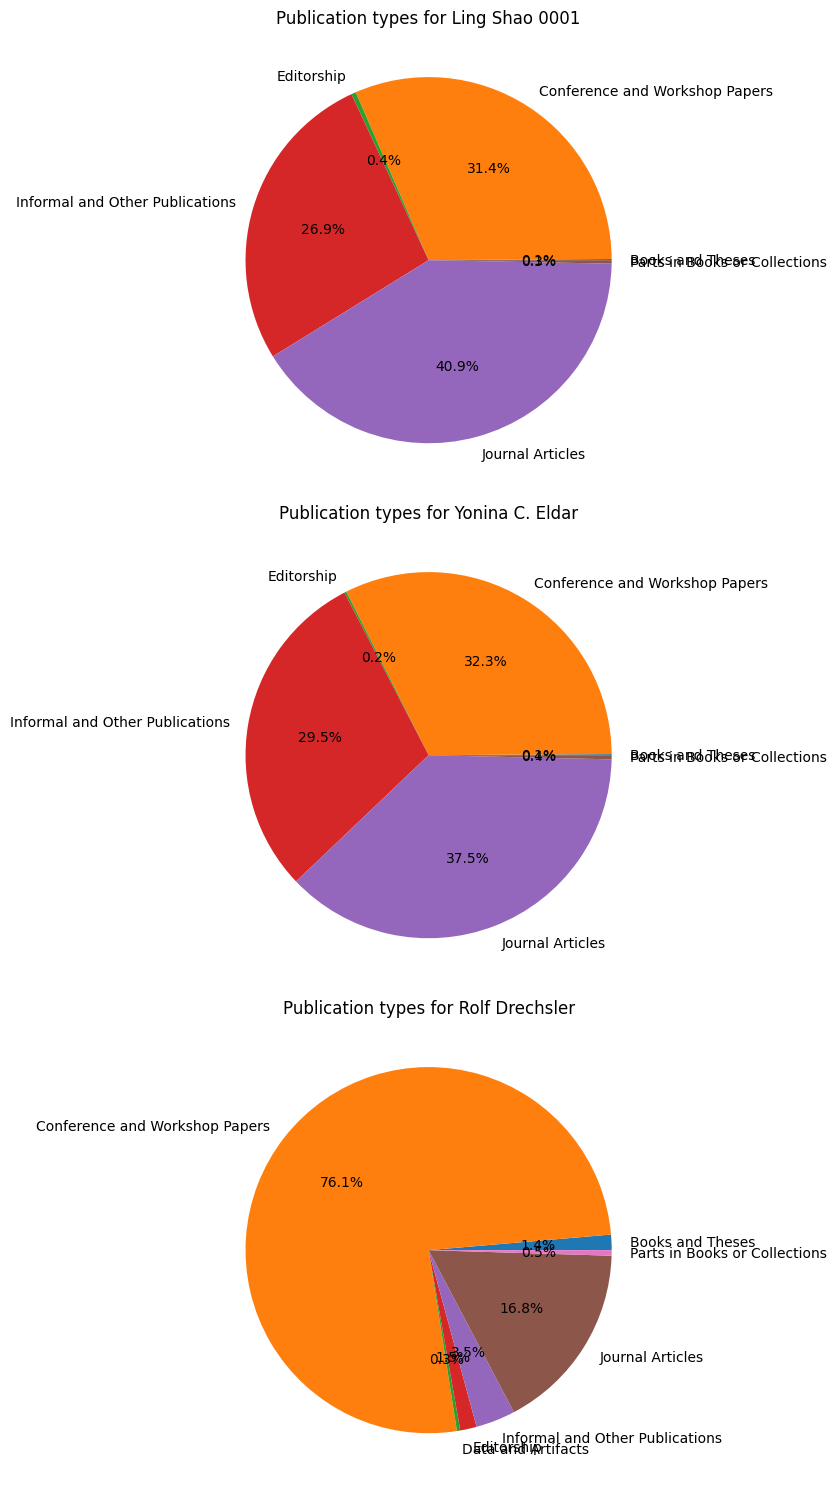

In [19]:
# Create subplots for each author for each publication type using 'matplotlib.pyplot'
fig, ax = plt.subplots(nrows=len(authors), ncols=1, figsize=(10, 15))

for i, (df, auth) in enumerate(zip(pubs_type, authors)):
    ax[i].pie(df['id'], labels=df['type'], autopct='%1.1f%%')
    ax[i].set_title(f"Publication types for {auth}")

plt.tight_layout()
plt.show()

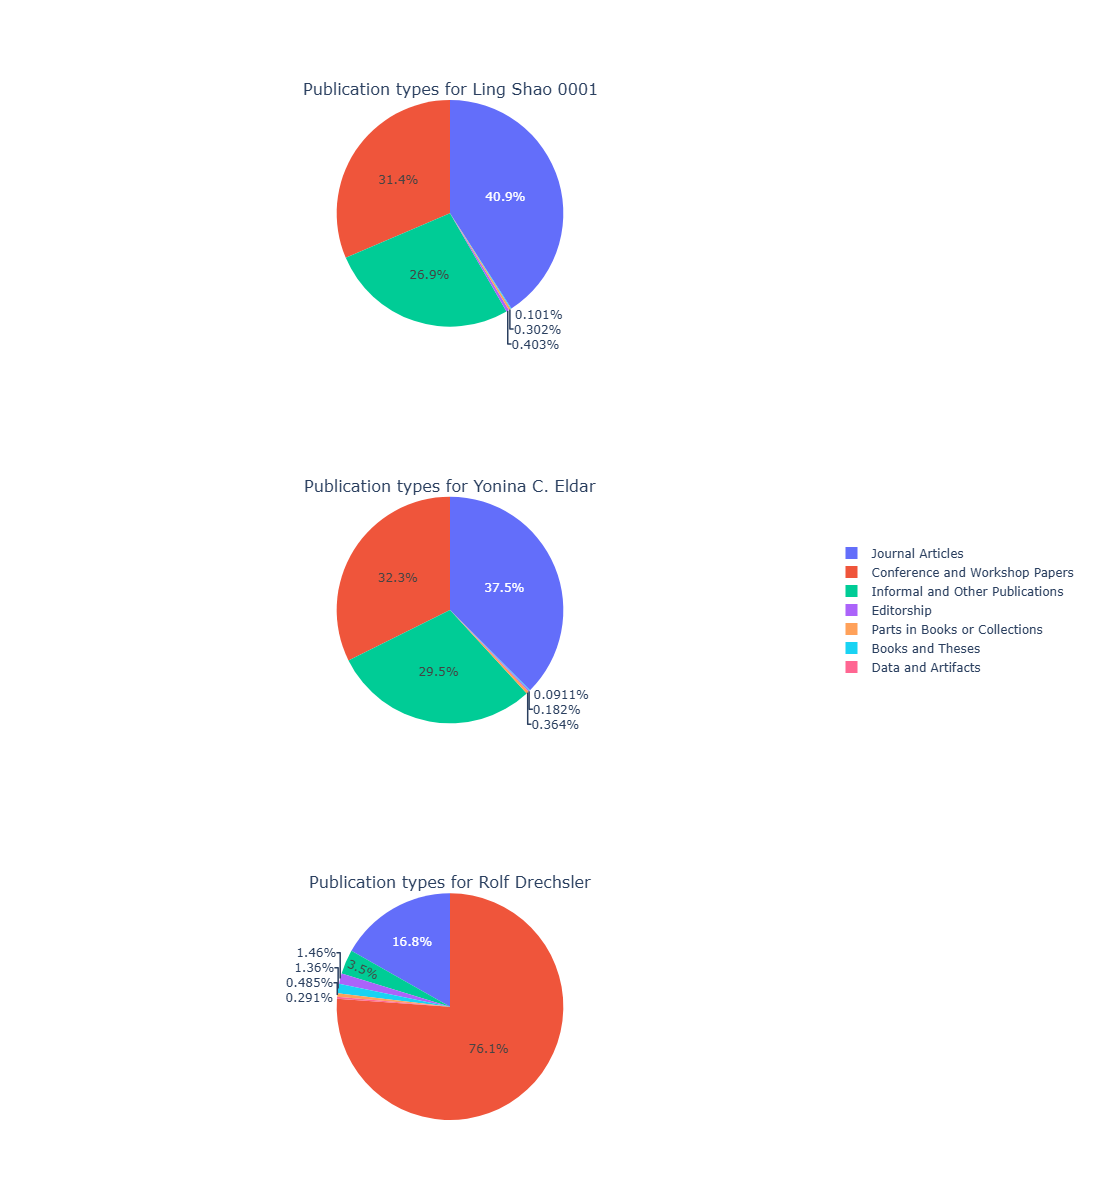

In [20]:
# Visualize the publication types for each author using 'plotly.graph_objects'
fig = make_subplots(rows=len(authors), cols=1,
                    subplot_titles=[f"Publication types for {auth}" for auth in authors],
                    specs=[[{'type': 'domain'}], [{'type': 'domain'}], [{'type': 'domain'}]])

for i, (df, auth) in enumerate(zip(pubs_type, authors)):
    fig.add_trace(
        go.Pie(labels=df['type'], values=df['id'], name=auth),
        row=i+1, col=1   
    )

        
fig.update_layout(
    height=1200,
    width=800,
    legend=dict(
        y=0.5,  
        yanchor='middle',  
        x=1.5,  
        xanchor='center'  
    )
)

fig.show()

In [21]:
# Convert lists in 'venue' column for each dataframe to strings
for df in merged_df:
    df['venue'] = df['venue'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

# Create a list with the publication count for each venue for each author
venue_counts = [merged_df[i].groupby(['venue'])['id'].count().reset_index() for i in range(len(merged_df))]
venue_counts[0]

,venue,id
0,AAAI,13
1,ACCV,2
2,ACIVS,1
3,ACM Multimedia,16
4,ACPR,1
...,...,...
103,Signal Process. Image Commun.,1
104,VCIP,1
105,VLDB J.,3
106,WACV,6


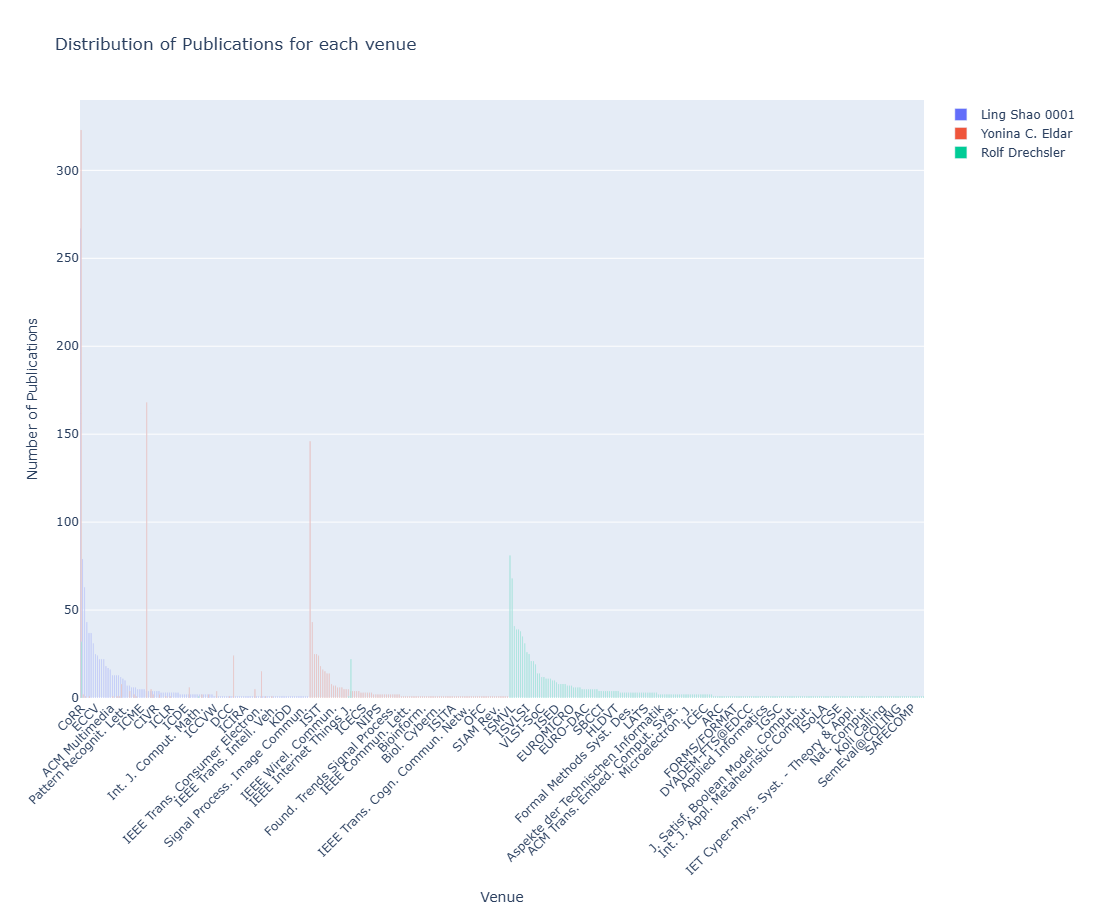

In [22]:
# Visualize the distribution of publications for each venue
fig = go.Figure()
for df, auth in zip(venue_counts, authors):
    df_sorted = df.sort_values(by="id", ascending=False)
    fig.add_trace(
        go.Bar(
            x=df_sorted["venue"],
            y=df_sorted["id"],
            name=auth
        )
    )
    
fig.update_layout(
    xaxis_title="Venue",
    yaxis_title="Number of Publications",
    title="Distribution of Publications for each venue",
    xaxis_tickangle=-45, 
    bargap=0.2,
    height=900,
    width=1300
)

fig.show()

In [23]:
# Create a list with the venue count per year for each author
venue_year = [merged_df[i].groupby(['year', 'venue']).size().reset_index(name='count') for i in range(len(merged_df))]

# Create a list with the most popular venues per year for each author
most_popular_venues = [venue_year[i].loc[venue_year[i].groupby('year')['count'].idxmax()] for i in range(len(venue_year))]
most_popular_venues[0]

,year,venue,count
0,2004,ECCV Workshops CVAMIA and MMBIA,1
1,2006,EUSIPCO,1
8,2007,ICME,3
14,2008,ICASSP,2
19,2009,CRV,2
22,2010,CIVR,4
30,2011,CoRR,2
49,2012,Pattern Recognit. Lett.,3
58,2013,IEEE Trans. Cybern.,3
70,2014,BMVC,4


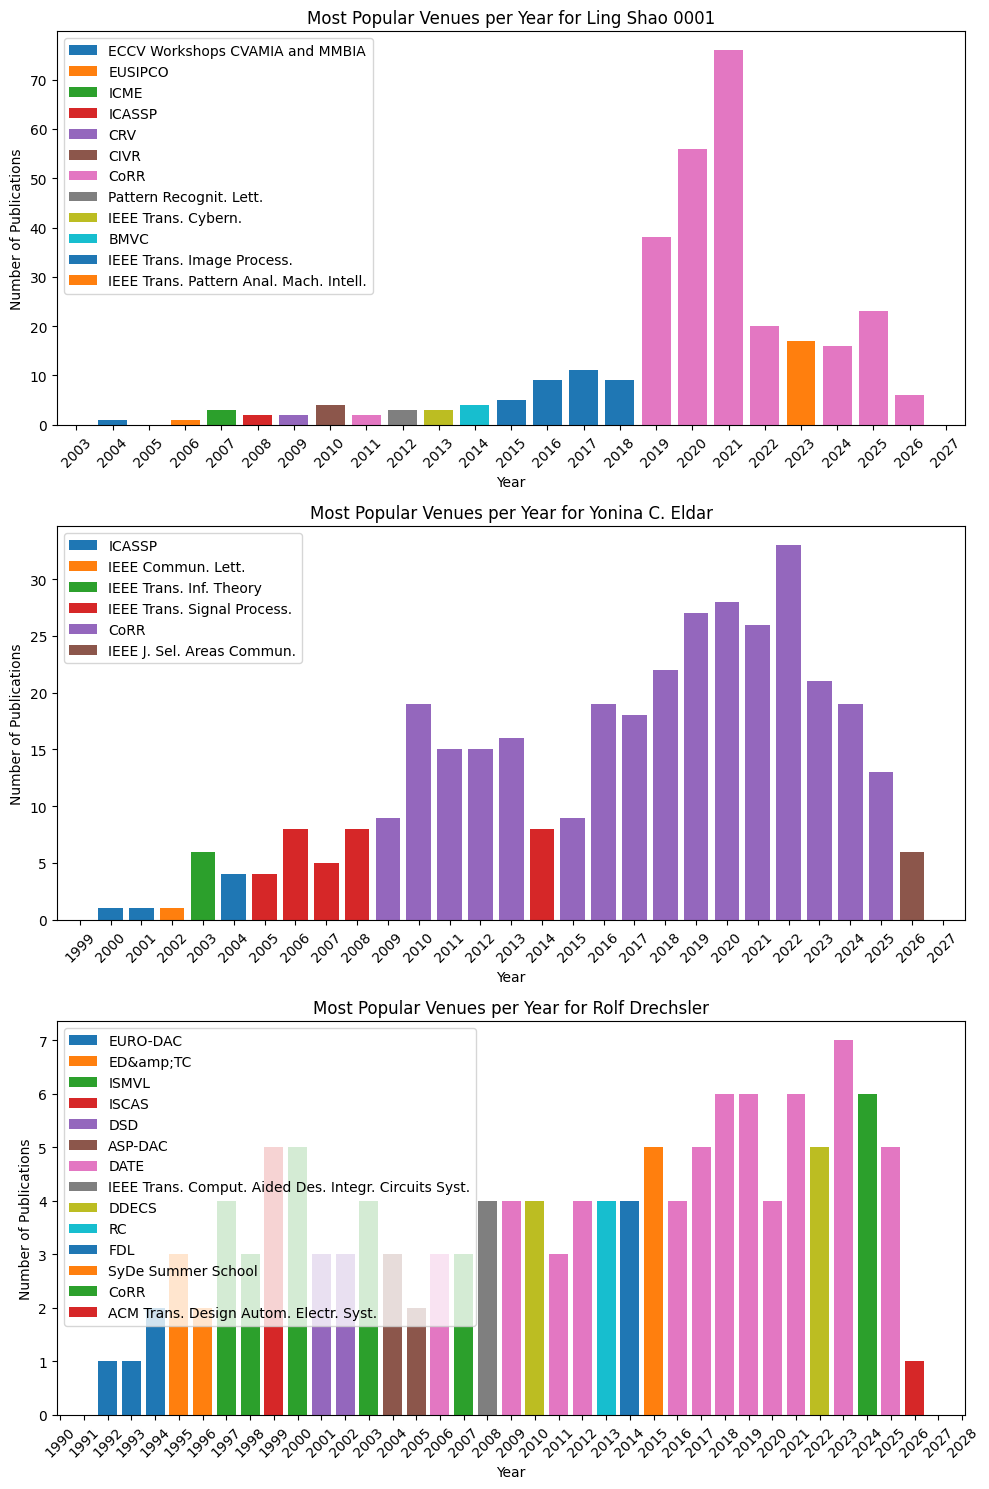

In [24]:
# Visualize the most popular venues per year using 'matplotlib.pyplot'
fig, ax = plt.subplots(nrows=len(authors), ncols=1, figsize=(10, 15))

for i, (df, auth) in enumerate(zip(most_popular_venues, authors)):
    # Convert 'year' column to numeric for completeness shake 
    df['year'] = pd.to_numeric(df['year'])

    # Iterate through unique venues to plot each one with its own color and label
    for venue in df['venue'].unique():
        # Filter data for the current venue
        venue_data = df[df['venue'] == venue]

        # Plot the bar chart for the current venue
        ax[i].bar(venue_data['year'], venue_data['count'], label=venue)

    # Set the title for each subplot
    ax[i].set_title(f"Most Popular Venues per Year for {auth}")

    # Set the x-axis label and rotate it by 45 degrees
    ax[i].set_xlabel('Year')
    ax[i].tick_params(axis='x', rotation=45)

    # Set the y-axis label
    ax[i].set_ylabel('Number of Publications')

    # Add a legend to each subplot
    ax[i].legend()
    
    # Use 'MultipleLocator' to set ticks on x-axis
    dtick = 1 
    ax[i].xaxis.set_major_locator(MultipleLocator(dtick))

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

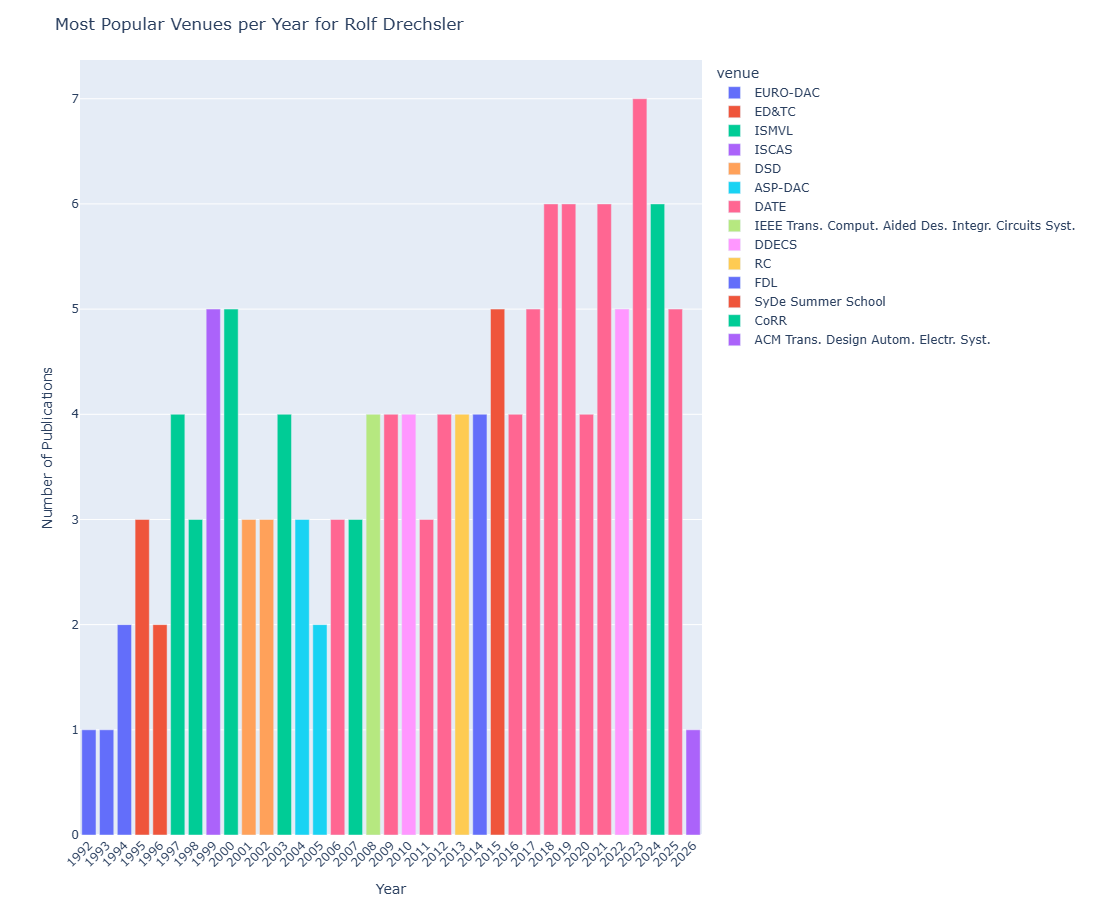

In [25]:
# Visualize the most popular venues per year for the third author
most_popular_venues[2]["year"] = pd.to_numeric(most_popular_venues[2]["year"])
fig = px.bar(most_popular_venues[2], x='year', y='count', color='venue')

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Number of Publications',
    title=f'Most Popular Venues per Year for {authors[2]}',
    xaxis=dict(
        tickangle=-45,
        tickmode='linear',
        dtick=1
    ), 
    bargap=0.2,
    height=900,
    width=1100
)

fig.show()

In [27]:
# Create a dictionary where the keys are our main authors' names
# and the values are the authors involved in each publication
all_authors = {}

# Iterate through each dataframe and author name pair
for df, auth in zip(merged_df, authors):
    # Initialize an empty list of lists for the current author
    all_authors[auth] = []        
    
    # Iterate through each publication's authors list
    for authors_str in df['authors']:
        
        # Check for missing values (NaN is considered as float)
        if isinstance(authors_str, str):
            # Collect each author's name in the current publication
            authors_collab = [a.strip() for a in authors_str.split(',')]
            
            # Remove the main author's name from the list of co-authors
            authors_collab.remove(auth)

        else:
            authors_collab = []
        
        # Append the list of co-authors to the author's list of lists
        all_authors[auth].append(authors_collab)
        
# Print the dictionary of authors and their corresponding lists of co-authors
# for author, colleagues in all_authors.items():
#     print(f"Author: {author}")
#     print("Co-authors per publication:")
#     for coll in colleagues:
#         print(coll)
#     print("\n"*4)  # For readability between authors

In [30]:
# Initialize an empty dictionary to store all colleagues
all_colleagues = {}

for author, colleagues in all_authors.items():
    # Flatten list of lists
    flat_list = [co for coll in colleagues for co in coll]
    
    # Count collaborations
    all_colleagues[author] = Counter(flat_list)

# Print the top N most frequent colleagues 
N = 5
for author, co_authors in all_colleagues.items():
    print(f"Most frequent colleagues for author {author}:")
    
    for name, count in co_authors.most_common(N):
        print(f"{name}: {count} collaborations")
    
    print()

Most frequent colleagues for author Ling Shao 0001:
Li Liu 0004: 147 collaborations
Jianbing Shen: 105 collaborations
Fan Zhu 0001: 86 collaborations
Xiantong Zhen: 66 collaborations
Fahad Shahbaz Khan: 65 collaborations

Most frequent colleagues for author Yonina C. Eldar:
Nir Shlezinger: 161 collaborations
Andrea J. Goldsmith: 48 collaborations
Haiyang Zhang 0001: 36 collaborations
Deborah Cohen: 34 collaborations
Tianyao Huang: 33 collaborations

Most frequent colleagues for author Rolf Drechsler:
Robert Wille: 218 collaborations
Daniel Große: 176 collaborations
Mathias Soeken: 88 collaborations
Görschwin Fey: 78 collaborations
Bernd Becker 0001: 76 collaborations



In [31]:
most_frequent_colleagues = {}
N = 7

for author, co_authors in all_colleagues.items():
    # Take top N most frequent colleagues directly
    top_n = co_authors.most_common(N)  # returns list of tuples (co_author, frequency)
    
    # Convert to dictionary
    most_frequent_colleagues[author] = dict(top_n)

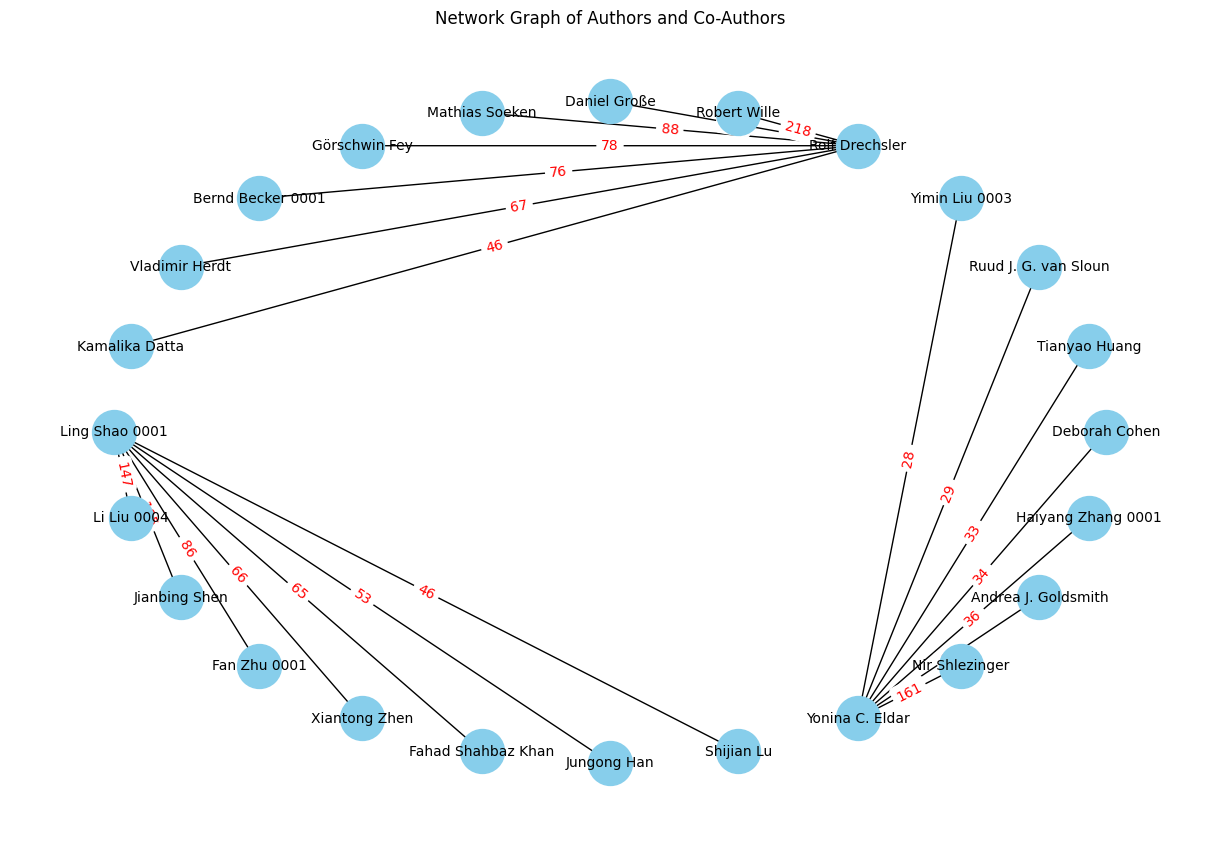

In [34]:
# Visualize the most frequent colleagues for each author with a Network Graph
G = nx.Graph()

# Add edges to the graph based on the most_frequent_colleagues data
for author, co_authors in most_frequent_colleagues.items():
    for co_author, count in co_authors.items():
        # Add an edge between the author and co-author with a weight equal to the count of collaborations
        G.add_edge(author, co_author, weight=count)

# Define the positions for the nodes 
pos = nx.shell_layout(G)  

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=10, font_color='black')

# Draw edge labels (weights) on the graph
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Set a title
plt.title('Network Graph of Authors and Co-Authors')

# Show the plot
plt.show()

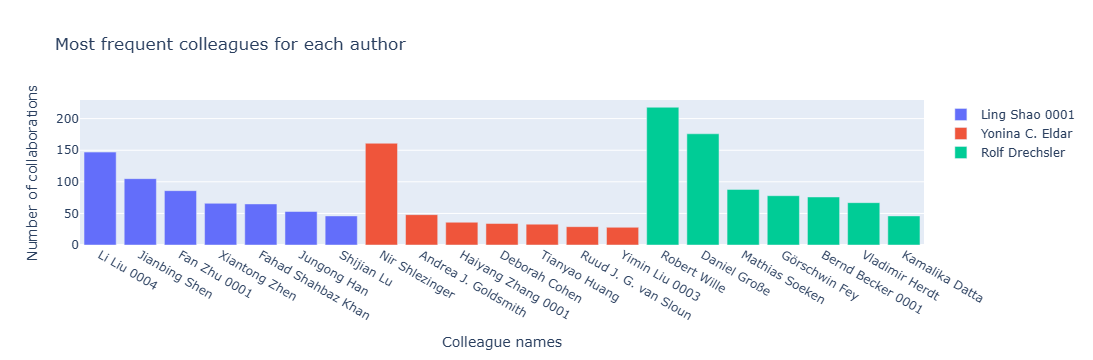

In [35]:
# Visualize the most frequent colleagues for each author with a barplot
fig = go.Figure()

for author, colleagues in most_frequent_colleagues.items():
    co_auth = list(colleagues.keys())
    collabs = list(colleagues.values())
    fig.add_trace(
        go.Bar(
            x=co_auth,
            y=collabs,
            name=author
        )
    )

# 
fig.update_layout(
    title='Most frequent colleagues for each author',
    xaxis_title='Colleague names',
    yaxis_title='Number of collaborations'
)

fig.show()